<a href="https://colab.research.google.com/github/gonatae2-hash/screw-detection/blob/main/YOLO/%EB%82%98%EC%82%AC_%EA%B2%80%EC%B6%9C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. 설치

In [ ]:
!pip install ultralytics roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 77.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.9/207.9 kB 24.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 20.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 90.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 138.3 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.13
    Uninstalling idna-3.13:
      Successfully uninstalled idna-3.13


# 2. 데이터셋 다운로드

In [ ]:
from roboflow import Roboflow
from google.colab import userdata

# 첫 번째 데이터셋 (직접 라벨링)
rf1 = Roboflow(api_key=userdata.get('ROBOFLOW_API_KEY_1'))
project1 = rf1.workspace("s-workspace-urypb").project("fastener-ydsnj")
dataset1 = project1.version(1).download("yolov8", location="/content/dataset1")

# 두 번째 데이터셋 (Fastener)
rf2 = Roboflow(api_key=userdata.get('ROBOFLOW_API_KEY_2'))
project2 = rf2.workspace("s-workspace-ogsll").project("screw-detection-sqibd")
dataset2 = project2.version(1).download("yolov8", location="/content/dataset2")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to /content/dataset1 in yolov8:: 100%|██████████| 613/613 [00:00<00:00, 8586.62it/s]


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to /content/dataset2 in yolov8:: 100%|██████████| 305/305 [00:00<00:00, 7263.71it/s]


# 3. 데이터셋 라벨 screw(0)으로 변환

In [ ]:
import os

def relabel_to_screw(label_dir):
    if not os.path.exists(label_dir):
        return
    for filename in os.listdir(label_dir):
        if not filename.endswith('.txt'):
            continue
        filepath = os.path.join(label_dir, filename)
        new_lines = []
        with open(filepath, 'r') as f:
            for line in f.readlines():
                parts = line.strip().split()
                if len(parts) >= 5:
                    parts[0] = '0'
                    new_lines.append(' '.join(parts))
        with open(filepath, 'w') as f:
            f.write('\n'.join(new_lines))

for split in ['train', 'valid', 'test']:
    relabel_to_screw(f'/content/dataset2/{split}/labels')

print("✅ 라벨 변환 완료!")

✅ 라벨 변환 완료!


# 4. 데이터셋 합치기

In [ ]:
import shutil

for split in ['train', 'valid', 'test']:
    os.makedirs(f'/content/merged/{split}/images', exist_ok=True)
    os.makedirs(f'/content/merged/{split}/labels', exist_ok=True)

def merge_dataset(src, split):
    img_src = f'{src}/{split}/images'
    lbl_src = f'{src}/{split}/labels'
    img_dst = f'/content/merged/{split}/images'
    lbl_dst = f'/content/merged/{split}/labels'

    if os.path.exists(img_src):
        for f in os.listdir(img_src):
            shutil.copy(f'{img_src}/{f}', f'{img_dst}/{f}')
    if os.path.exists(lbl_src):
        for f in os.listdir(lbl_src):
            shutil.copy(f'{lbl_src}/{f}', f'{lbl_dst}/{f}')

for split in ['train', 'valid', 'test']:
    merge_dataset('/content/dataset1', split)
    merge_dataset('/content/dataset2', split)

# 5. data.yaml 생성

In [ ]:
yaml_content = """train: /content/merged/train/images
val: /content/merged/valid/images
test: /content/merged/test/images

nc: 1
names: ['screw']
"""

with open('/content/merged/data.yaml', 'w') as f:
    f.write(yaml_content)

print("✅ data.yaml 생성 완료!")

✅ data.yaml 생성 완료!


# 6. YOLOv8 학습

In [ ]:
from ultralytics import YOLO

model = YOLO('yolov8n.pt')

model.train(
    data='/content/merged/data.yaml',
    epochs=50,
    imgsz=640,
    batch=16,
    name='screw_detection',
    project='/content/runs'
)

print("✅ 학습 완료!")

Ultralytics 8.4.47 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/merged/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=screw_detection, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patienc

# 7. best.pt 구글 드라이브 저장

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

shutil.copy(
    '/content/runs/screw_detection/weights/best.pt',
    '/content/drive/MyDrive/screw_best.pt'
)

print("✅ best.pt 저장 완료!")

Mounted at /content/drive
✅ best.pt 저장 완료!


# 8. 학습 결과 확인

Saving WIN_20260508_10_44_59_Pro.jpg to WIN_20260508_10_44_59_Pro.jpg

image 1/1 /content/WIN_20260508_10_44_59_Pro.jpg: 384x640 1 screw, 41.8ms
Speed: 2.2ms preprocess, 41.8ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 640)


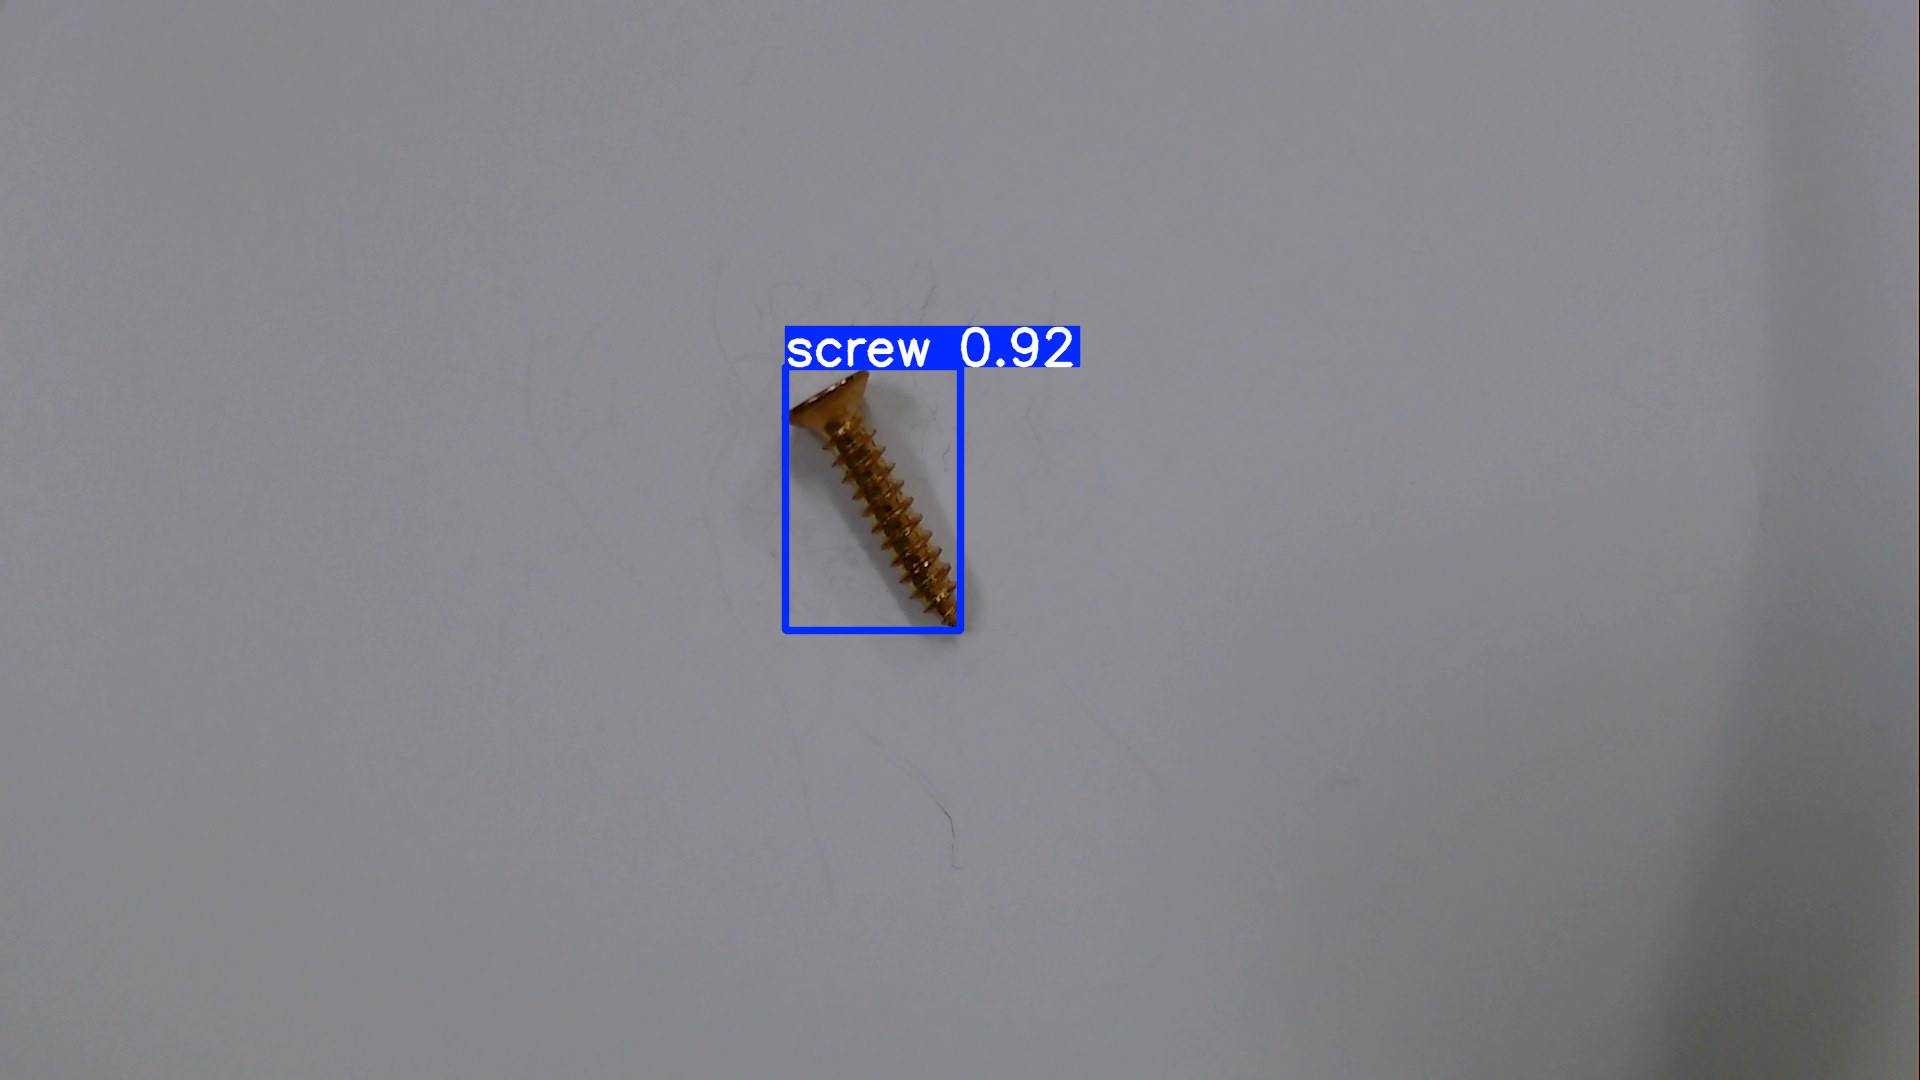

✅ 검출된 나사 수: 1개


In [ ]:
from ultralytics import YOLO
from google.colab import files
import cv2
from google.colab.patches import cv2_imshow

# 학습된 모델 불러오기
model = YOLO('/content/runs/screw_detection/weights/best.pt')

# 사진 업로드
uploaded = files.upload()  # ← 여기서 사진 선택하면 됨

# 검출 실행
for filename in uploaded.keys():
    results = model(filename, conf=0.25)  # conf=0.25 (신뢰도 25% 이상만 검출)

    # 결과 이미지 표시
    for r in results:
        img = r.plot()  # 박스 그려진 이미지
        cv2_imshow(img)

        # 검출된 나사 개수 출력
        print(f"✅ 검출된 나사 수: {len(r.boxes)}개")